In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score



In [35]:
df=pd.read_csv('student_performance_finalscore.csv')

df_clean=df.drop('Student_ID',axis=1)

print(df_clean.isnull().sum())

Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Final_Score                   0
dtype: int64


In [36]:
from sklearn.model_selection import train_test_split

# training and test part 
# 1. Metinleri sayıya çevirmek için bu satırı ekle
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# 2. X değişkenini oluşturmadan hemen önce şu döngüyü çalıştır
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col])

X = df_clean.drop('Final_Score', axis=1)
y = df_clean['Final_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Veri %80 eğitim, %20 test olarak başarıyla ayrıldı.")

Veri %80 eğitim, %20 test olarak başarıyla ayrıldı.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_44888\1885533797.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


In [37]:
# Tahmin etmek istediğimiz hedef sütun: Final_Score
y = df_clean['Final_Score']

# Girdi özelliklerimiz ise Final_Score dışındaki her şey
X = df_clean.drop('Final_Score', axis=1)

In [38]:
from sklearn.model_selection import train_test_split

# test_size=0.20 yazarak %20'lik kısmı test için ayırıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Kontrol edelim (Toplam 8000 veri vardı)
print(f"Eğitim seti (6400 olmalı): {len(X_train)}")
print(f"Test seti (1600 olmalı): {len(X_test)}")

Eğitim seti (6400 olmalı): 6400
Test seti (1600 olmalı): 1600


In [39]:
from sklearn.ensemble import RandomForestRegressor

# Modeli oluştur
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Modeli %80'lik eğitim verisiyle eğit
model.fit(X_train, y_train)

print("Model başarıyla eğitildi!")

Model başarıyla eğitildi!


In [40]:
from sklearn.metrics import r2_score, mean_absolute_error

# Modelin görmediği X_test verileriyle tahmin yapalım
y_pred = model.predict(X_test)

# Gerçek sonuçlarla (y_test) tahminleri (y_pred) karşılaştıralım
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Başarı Oranı (R2): %{r2*100:.2f}")
print(f"Ortalama Hata Payı (MAE): {mae:.2f} puan")

Başarı Oranı (R2): %70.15
Ortalama Hata Payı (MAE): 5.46 puan


C:\Users\ASUS\AppData\Local\Temp\ipykernel_44888\736621912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Özellik', data=importance_df, palette='viridis')


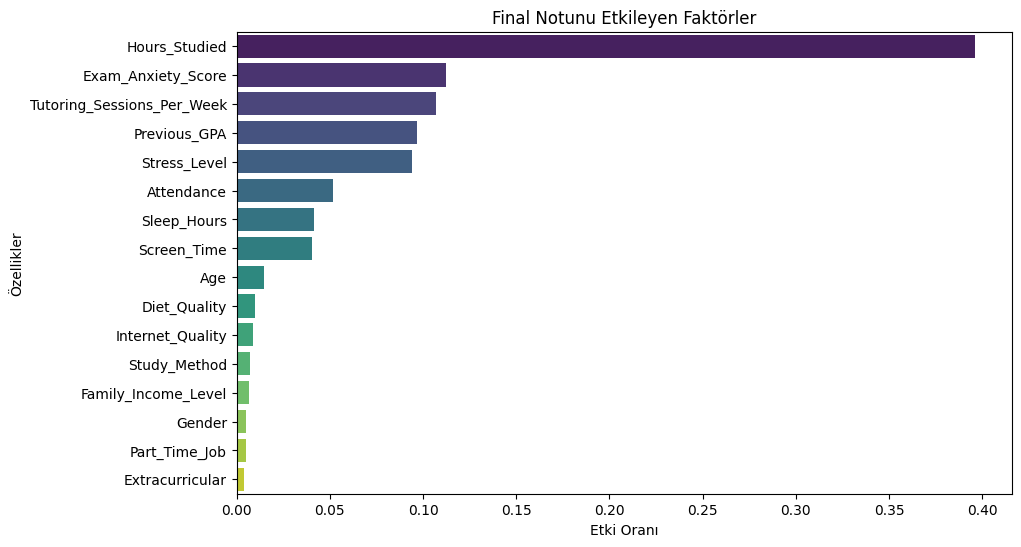

In [41]:
# 1. Özellik Önem Sıralaması Grafiği
plt.figure(figsize=(10,6))
importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Özellik': features, 'Önem': importances}).sort_values(by='Önem', ascending=False)

sns.barplot(x='Önem', y='Özellik', data=importance_df, palette='viridis')
plt.title('Final Notunu Etkileyen Faktörler')
plt.xlabel('Etki Oranı')
plt.ylabel('Özellikler')
plt.show() # Bu satır grafiği ekrana basar

In [42]:
def not_tahmin_et():
    print("--- Öğrenci Not Tahmin Sistemi ---")
    
    # Kullanıcıdan bazı önemli verileri alalım
    saat = float(input("Günde kaç saat çalışıyorsunuz? (Örn: 5.5): "))
    devam = float(input("Derse katılım oranınız yüzde kaç? (Örn: 85): "))
    eski_gpa = float(input("Önceki dönem ortalamanız nedir? (Örn: 3.0): "))
    kaygi = float(input("Sınav kaygı seviyeniz nedir? (1-10 arası): "))
    uyku = float(input("Günde ortalama kaç saat uyuyorsunuz?: "))
    
    # Modelin eğitildiği formata (X_train sütun sayısı) uyması için 
    # diğer sütunları ortalama değerlerle dolduran bir taslak veri oluşturalım
    # Not: X.mean() kullanarak diğer tüm özellikleri (cinsiyet, diyet vb.) sabitliyoruz.
    yeni_veri = X.mean().values.copy()
    
    # Sütunların indekslerine göre kullanıcının girdiği verileri yerleştirelim
    # Not: Sütun isimlerinizin sırası X.columns ile aynı olmalı
    yeni_veri[X.columns.get_loc('Hours_Studied')] = saat
    yeni_veri[X.columns.get_loc('Attendance')] = devam
    yeni_veri[X.columns.get_loc('Previous_GPA')] = eski_gpa
    yeni_veri[X.columns.get_loc('Exam_Anxiety_Score')] = kaygi
    yeni_veri[X.columns.get_loc('Sleep_Hours')] = uyku
    
    # Tahmin yap
    tahmin = model.predict([yeni_veri])
    
    print(f"\n[SONUÇ]: Girdiğiniz verilere göre beklenen Final Notunuz: {tahmin[0]:.2f}")

# Fonksiyonu çalıştır
not_tahmin_et()


--- Öğrenci Not Tahmin Sistemi ---

[SONUÇ]: Girdiğiniz verilere göre beklenen Final Notunuz: 92.29


c:\Users\ASUS\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
